### Testtttttttt

In [10]:
import pandas as pd
import os
import sys

In [11]:
df = pd.read_csv("../data/raw/yellow_tripdata_2016-03.csv")

df.head()

KeyboardInterrupt: 

In [3]:
df.describe()

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,1.221095e+07,1.221095e+07,1.221095e+07,1.221095e+07,1.221095e+07,1.221095e+07,1.221095e+07,1.221095e+07,1.221095e+07,1.221095e+07,1.221095e+07,1.221095e+07,1.221095e+07,1.221095e+07,1.221095e+07,1.221095e+07
mean,1.530647e+00,1.659580e+00,6.131770e+00,-7.287133e+01,4.014349e+01,1.040395e+00,-7.293679e+01,4.018050e+01,1.340920e+00,1.279508e+01,3.455600e-01,4.976363e-01,1.792582e+00,3.152554e-01,2.997199e-01,1.604582e+01
std,4.990599e-01,1.312189e+00,6.156483e+03,8.964108e+00,4.937996e+00,5.807342e-01,8.696974e+00,4.790940e+00,4.902621e-01,1.340979e+02,4.563069e-01,4.863319e-02,2.549124e+00,1.751526e+00,1.230647e-02,1.343578e+02
min,1.000000e+00,0.000000e+00,0.000000e+00,-1.616987e+02,0.000000e+00,1.000000e+00,-1.616987e+02,0.000000e+00,1.000000e+00,-3.760000e+02,-5.850000e+01,-1.000000e+00,-2.000000e+01,-1.604000e+01,-3.000000e-01,-3.763000e+02
25%,1.000000e+00,1.000000e+00,1.000000e+00,-7.399174e+01,4.073630e+01,1.000000e+00,-7.399125e+01,4.073462e+01,1.000000e+00,6.500000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,3.000000e-01,8.750000e+00
50%,2.000000e+00,1.000000e+00,1.700000e+00,-7.398161e+01,4.075325e+01,1.000000e+00,-7.397961e+01,4.075375e+01,1.000000e+00,9.500000e+00,0.000000e+00,5.000000e-01,1.350000e+00,0.000000e+00,3.000000e-01,1.180000e+01
75%,2.000000e+00,2.000000e+00,3.180000e+00,-7.396678e+01,4.076765e+01,1.000000e+00,-7.396228e+01,4.076910e+01,2.000000e+00,1.450000e+01,5.000000e-01,5.000000e-01,2.360000e+00,0.000000e+00,3.000000e-01,1.776000e+01
max,2.000000e+00,9.000000e+00,1.907263e+07,0.000000e+00,6.685682e+01,9.900000e+01,0.000000e+00,5.079786e+01,4.000000e+00,4.294967e+05,8.000000e+01,7.930000e+01,8.500000e+02,1.410320e+03,3.000000e-01,4.295622e+05


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12210952 entries, 0 to 12210951
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        int64  
 4   trip_distance          float64
 5   pickup_longitude       float64
 6   pickup_latitude        float64
 7   RatecodeID             int64  
 8   store_and_fwd_flag     object 
 9   dropoff_longitude      float64
 10  dropoff_latitude       float64
 11  payment_type           int64  
 12  fare_amount            float64
 13  extra                  float64
 14  mta_tax                float64
 15  tip_amount             float64
 16  tolls_amount           float64
 17  improvement_surcharge  float64
 18  total_amount           float64
dtypes: float64(12), int64(4), object(3)
memory usage: 1.7+ GB


In [8]:
df['trip_duration'] = (pd.to_datetime(df['tpep_dropoff_datetime']) - pd.to_datetime(df['tpep_pickup_datetime'])).dt.total_seconds()

In [ ]:
df.loc[(df['trip_duration'] == 0) & (df['trip_distance'] == 0), 'trip_distance']

47691       0.0
49750       0.0
61176       0.0
65540       0.0
65769       0.0
           ... 
12205244    0.0
12207125    0.0
12208277    0.0
12209016    0.0
12210947    0.0
Name: trip_distance, Length: 12101, dtype: float64

Test preprocessing

In [4]:
from taxi_preprocessing import (
    preprocess_taxi_df,
    save_processed,
    load_sampled_data
)

# 1. Sample
df_sample = load_sampled_data(
    "../data/raw/yellow_tripdata_2016-03.csv", 
    sample_frac=0.05
)

# 2. Clean
df_clean = preprocess_taxi_df(df_sample)

# 3. Save
save_processed(df_clean, "../data/processed/taxi_cleaned.csv")

print(df_clean.head())

       VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
75721         1  2016-03-01 01:03:46   2016-03-01 01:09:36                1   
80184         1  2016-03-01 01:25:12   2016-03-01 01:33:39                1   
19864         2  2016-03-10 08:51:47   2016-03-10 09:30:18                1   
76699         2  2016-03-10 13:40:52   2016-03-10 14:00:44                1   
92991         2  2016-03-01 06:05:48   2016-03-01 06:23:13                2   

       trip_distance  pickup_longitude  pickup_latitude  RatecodeID  \
75721           1.70        -74.010620        40.747231           1   
80184           3.10        -73.968529        40.754086           1   
19864           8.79        -74.007736        40.740559           1   
76699           3.02        -73.979660        40.754799           1   
92991           9.69        -73.972130        40.754021           1   

      store_and_fwd_flag  dropoff_longitude  ...  total_amount  trip_duration  \
75721            

In [2]:
# Check processed data
print(df_clean.shape)
print(df_clean.info())
print(df_clean.describe())

(570481, 28)
<class 'pandas.core.frame.DataFrame'>
Index: 570481 entries, 75721 to 12207900
Data columns (total 28 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               570481 non-null  int64         
 1   tpep_pickup_datetime   570481 non-null  datetime64[ns]
 2   tpep_dropoff_datetime  570481 non-null  datetime64[ns]
 3   passenger_count        570481 non-null  int64         
 4   trip_distance          570481 non-null  float64       
 5   pickup_longitude       570481 non-null  float64       
 6   pickup_latitude        570481 non-null  float64       
 7   RatecodeID             570481 non-null  int64         
 8   store_and_fwd_flag     570481 non-null  object        
 9   dropoff_longitude      570481 non-null  float64       
 10  dropoff_latitude       570481 non-null  float64       
 11  payment_type           570481 non-null  int64         
 12  fare_amount            570481 

Pickup longitude = 0: 0
Pickup latitude = 0: 0
Dropoff longitude = 0: 0
Dropoff latitude = 0: 0
Trip distance <= 0: 0
Fare <= 0: 0
Total <= 0: 0
Trip duration <= 0: 0
Passenger = 0: 0
       trip_distance  trip_duration    fare_amount
count  570481.000000  570481.000000  570481.000000
mean        2.435315     747.531590      11.159694
std         2.273118     474.124506       6.726189
min         0.110000      61.000000       3.000000
25%         1.000000     390.000000       6.500000
50%         1.660000     635.000000       9.000000
75%         2.900000     995.000000      13.500000
max        13.340000    2663.000000      52.000000


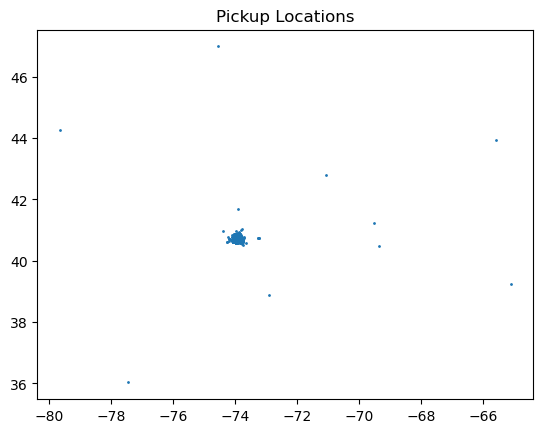

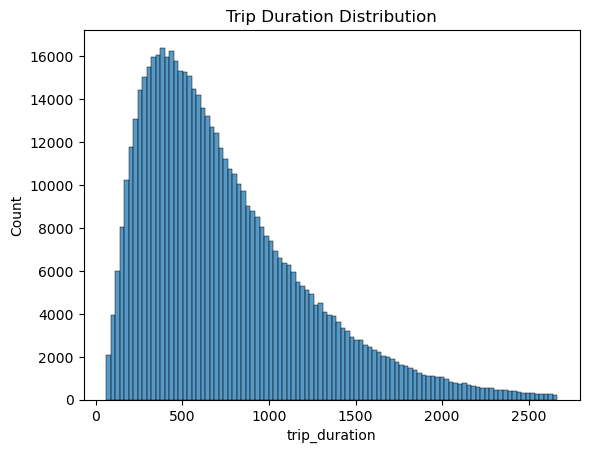

In [3]:
print("Pickup longitude = 0:", (df_clean['pickup_longitude'] == 0).sum())
print("Pickup latitude = 0:", (df_clean['pickup_latitude'] == 0).sum())

print("Dropoff longitude = 0:", (df_clean['dropoff_longitude'] == 0).sum())
print("Dropoff latitude = 0:", (df_clean['dropoff_latitude'] == 0).sum())

print("Trip distance <= 0:", (df_clean['trip_distance'] <= 0).sum())
print("Fare <= 0:", (df_clean['fare_amount'] <= 0).sum())
print("Total <= 0:", (df_clean['total_amount'] <= 0).sum())

print("Trip duration <= 0:", (df_clean['trip_duration'] <= 0).sum())

print("Passenger = 0:", (df_clean['passenger_count'] == 0).sum())

print(df_clean[['trip_distance', 'trip_duration', 'fare_amount']].describe())

import matplotlib.pyplot as plt

plt.scatter(df_clean['pickup_longitude'], df_clean['pickup_latitude'], s=1)
plt.title("Pickup Locations")
plt.show()

import seaborn as sns

sns.histplot(df_clean['trip_duration'], bins=100)
plt.title("Trip Duration Distribution")
plt.show()

test traffic

In [1]:
from traffic_preprocessing import *

df = load_data("../data/raw/Metro_Interstate_Traffic_Volume.csv")

df_clean = preprocess_traffic(df)

save_processed(df_clean, "../data/processed/traffic_cleaned.csv")

print(df_clean.head())

            date_time    temp  rain_1h  snow_1h  clouds_all  traffic_volume  \
0 2012-10-02 09:00:00  288.28      0.0      0.0        40.0          5545.0   
1 2012-10-02 10:00:00  289.36      0.0      0.0        75.0          4516.0   
2 2012-10-02 11:00:00  289.58      0.0      0.0        90.0          4767.0   
3 2012-10-02 12:00:00  290.13      0.0      0.0        90.0          5026.0   
4 2012-10-02 13:00:00  291.14      0.0      0.0        75.0          4918.0   

   hour  dayofweek  month  is_weekend  ...  weather_main_Drizzle  \
0   9.0        1.0   10.0         0.0  ...                   0.0   
1  10.0        1.0   10.0         0.0  ...                   0.0   
2  11.0        1.0   10.0         0.0  ...                   0.0   
3  12.0        1.0   10.0         0.0  ...                   0.0   
4  13.0        1.0   10.0         0.0  ...                   0.0   

   weather_main_Fog  weather_main_Haze  weather_main_Mist  weather_main_Rain  \
0               0.0                0

Shape: (51972, 23)

Missing values:
 date_time                    0
temp                         0
rain_1h                      0
snow_1h                      0
clouds_all                   0
traffic_volume               0
hour                         0
dayofweek                    0
month                        0
is_weekend                   0
is_peak_hour                 0
is_holiday                   0
weather_main_Clouds          0
weather_main_Drizzle         0
weather_main_Fog             0
weather_main_Haze            0
weather_main_Mist            0
weather_main_Rain            0
weather_main_Smoke           0
weather_main_Snow            0
weather_main_Squall          0
weather_main_Thunderstorm    0
temp_c                       0
dtype: int64

Time range: 2012-10-02 09:00:00 → 2018-09-30 23:00:00
Duplicate time: 0

Traffic stats:
 count    51972.000000
mean      3072.151618
std       1922.730657
min          0.000000
25%       1226.000000
50%       2892.000000
75%       4775.

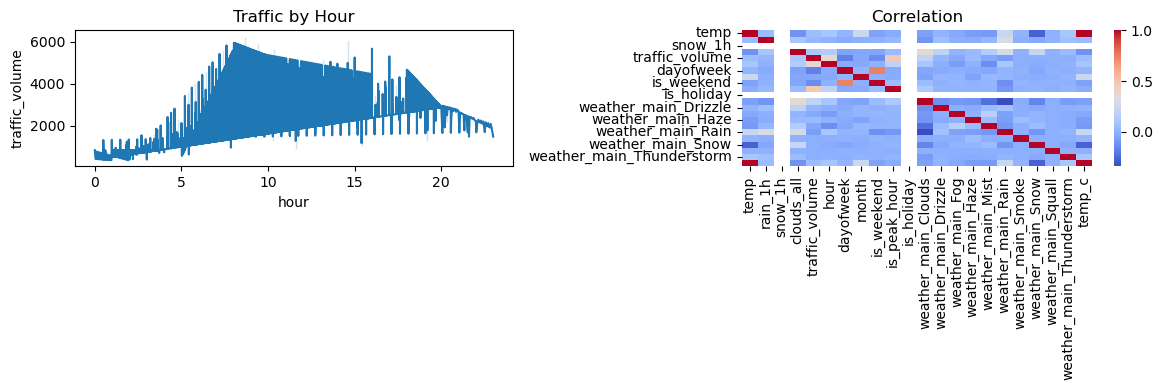

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# ===== 1. Tổng quan =====
print("Shape:", df_clean.shape)
print("\nMissing values:\n", df_clean.isnull().sum())

# ===== 2. Time check =====
print("\nTime range:", df_clean['date_time'].min(), "→", df_clean['date_time'].max())
print("Duplicate time:", df_clean['date_time'].duplicated().sum())

# ===== 3. Thống kê chính =====
print("\nTraffic stats:\n", df_clean['traffic_volume'].describe())
print("\nRain stats:\n", df_clean['rain_1h'].describe())

# ===== 4. Feature check =====
print("\nHoliday:\n", df_clean['is_holiday'].value_counts())
print("\nPeak hour:\n", df_clean['is_peak_hour'].value_counts())

# ===== 5. Visualization =====
plt.figure(figsize=(12,4))

# Traffic theo giờ
plt.subplot(1,2,1)
sns.lineplot(x='hour', y='traffic_volume', data=df_clean)
plt.title("Traffic by Hour")

# Correlation
plt.subplot(1,2,2)
sns.heatmap(df_clean.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation")

plt.tight_layout()
plt.show()